In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df=pd.read_csv("Cardiotocographic.csv")
print(df.head())

           LB        AC   FM        UC        DL   DS   DP  ASTV  MSTV  ALTV  \
0  120.000000  0.000000  0.0  0.000000  0.000000  0.0  0.0  73.0   0.5  43.0   
1  132.000000  0.006380  0.0  0.006380  0.003190  0.0  0.0  17.0   2.1   0.0   
2  133.000000  0.003322  0.0  0.008306  0.003322  0.0  0.0  16.0   2.1   0.0   
3  134.000000  0.002561  0.0  0.007742  0.002561  0.0  0.0  16.0   2.4   0.0   
4  131.948232  0.006515  0.0  0.008143  0.000000  0.0  0.0  16.0   2.4   0.0   

   MLTV  Width  Tendency  NSP  
0   2.4   64.0  0.999926  2.0  
1  10.4  130.0  0.000000  1.0  
2  13.4  130.0  0.000000  1.0  
3  23.0  117.0  1.000000  1.0  
4  19.9  117.0  1.000000  1.0  


In [7]:
df.info

<bound method DataFrame.info of               LB        AC        FM        UC        DL   DS   DP  ASTV  \
0     120.000000  0.000000  0.000000  0.000000  0.000000  0.0  0.0  73.0   
1     132.000000  0.006380  0.000000  0.006380  0.003190  0.0  0.0  17.0   
2     133.000000  0.003322  0.000000  0.008306  0.003322  0.0  0.0  16.0   
3     134.000000  0.002561  0.000000  0.007742  0.002561  0.0  0.0  16.0   
4     131.948232  0.006515  0.000000  0.008143  0.000000  0.0  0.0  16.0   
...          ...       ...       ...       ...       ...  ...  ...   ...   
2121  140.000000  0.000000  0.961268  0.007426  0.000000  0.0  0.0  79.0   
2122  140.000000  0.000775  0.000000  0.006979  0.000000  0.0  0.0  78.0   
2123  140.000000  0.000980  0.000000  0.006863  0.000000  0.0  0.0  79.0   
2124  140.000000  0.000679  0.000000  0.006110  0.000000  0.0  0.0  78.0   
2125  142.000000  0.001616 -0.000188  0.008078  0.000000  0.0  0.0  74.0   

      MSTV       ALTV  MLTV  Width  Tendency       NSP 

In [9]:
df.isnull().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [13]:
for col in df.columns:
    df[col] = df[col].fillna(df[col].median())
    if df[col].dtype in ['float64' , 'int64']:
        df.fillna({col: df[col].median()}, inplace=True)


In [15]:
df.isnull().sum()

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

In [17]:
df.dtypes

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object

In [19]:
for c in df.columns:
    if df[c].dtype =='object':
        df[c]=pd.to_numeric(df[c],errors='coerce')

In [21]:
df.isnull().sum()

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

In [23]:
# IQR-based outlier detection
for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)


In [27]:
outliers = ((df[col] < lower) | (df[col] > upper)).sum()
print(f"{col}: {outliers} outliers")

NSP: 0 outliers


In [43]:
desc = df.describe().T
desc['median'] = df.median()
desc['IQR'] = df.quantile(0.75) - df.quantile(0.25)
desc

,count,mean,std,min,25%,50%,75%,max,median,IQR
LB,2126.0,133.290331,9.930268,105.000000,126.000000,133.000000,140.000000,161.000000,133.000000,14.000000
AC,2126.0,0.003132,0.003828,-0.008409,0.000000,0.001634,0.005606,0.014015,0.001634,0.005606
FM,2126.0,0.001568,0.002485,-0.003850,0.000000,0.000000,0.002567,0.006416,0.000000,0.002567
UC,2126.0,0.004362,0.003001,-0.005177,0.001851,0.004484,0.006536,0.013564,0.004484,0.004685
DL,2126.0,0.001770,0.002668,-0.004934,0.000000,0.000000,0.003289,0.008224,0.000000,0.003289
DS,2126.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
DP,2126.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ASTV,2126.0,46.981873,17.612745,-11.500000,32.000000,49.000000,61.000000,104.500000,49.000000,29.000000
MSTV,2126.0,1.304644,0.781091,-0.800000,0.700000,1.200000,1.700000,3.200000,1.200000,1.000000
ALTV,2126.0,6.691678,10.378400,-16.500000,0.000000,0.000000,11.000000,27.500000,0.000000,11.000000


**Findings**

- Look for large differences between mean and median , indicates skewness.
- High standard deviation ,variable with more variability.

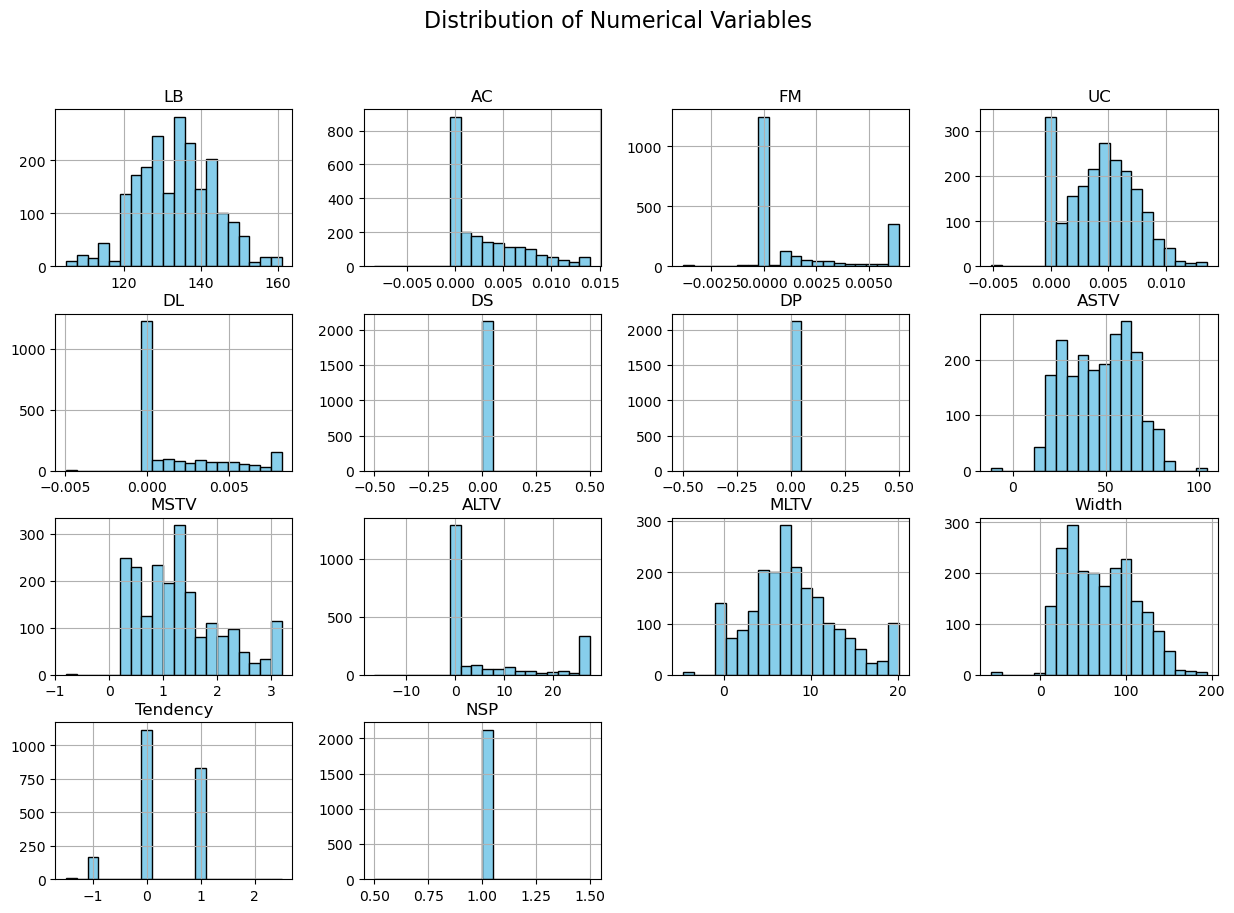

In [61]:
#Histogram
df.hist(figsize=(15,10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Numerical Variables', fontsize=16)
plt.show()


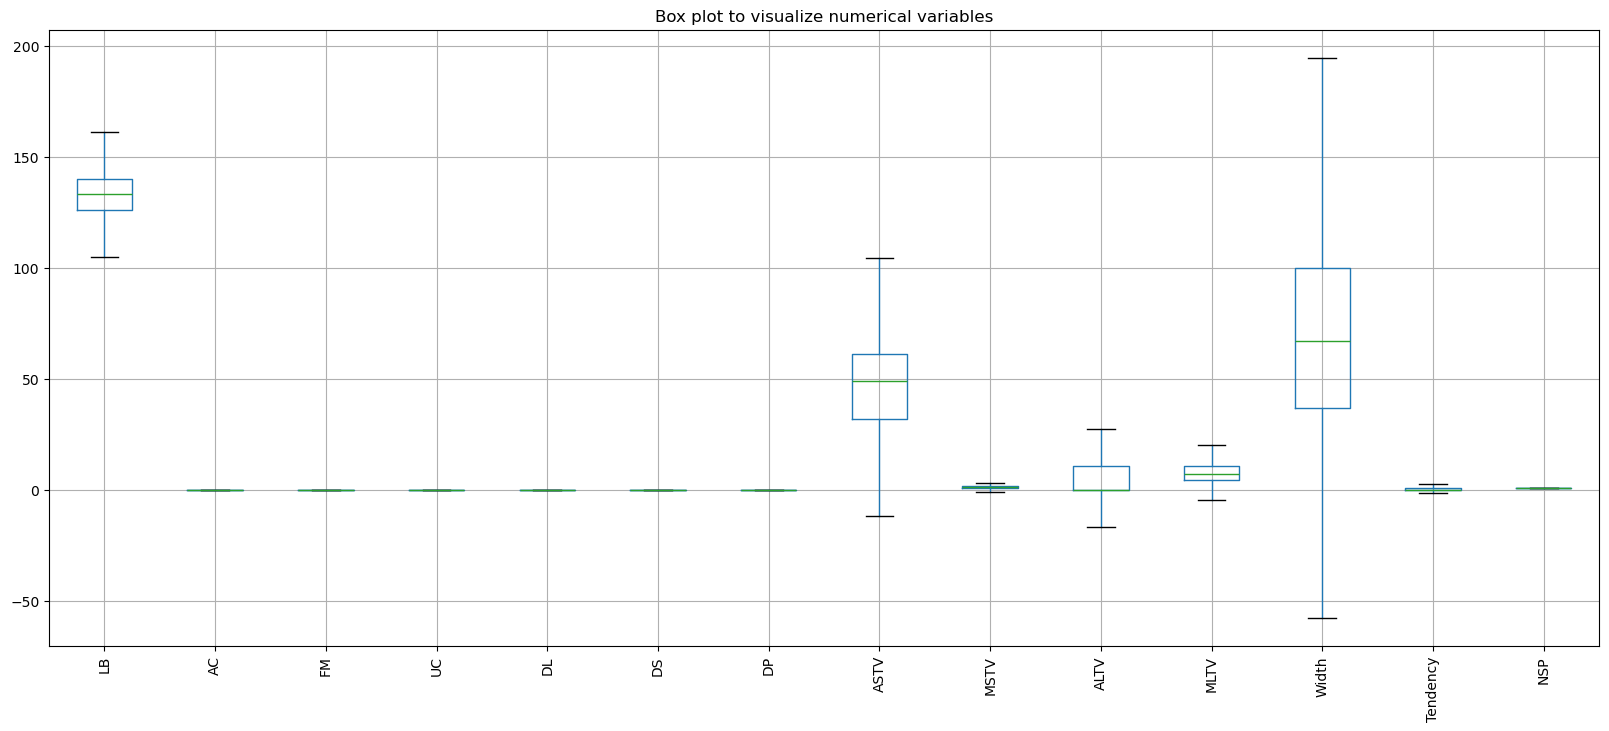

In [63]:
#Box Plot
plt.figure(figsize=(20,8))
df.boxplot(rot=90)
plt.title("Box plot to visualize numerical variables")
plt.show()

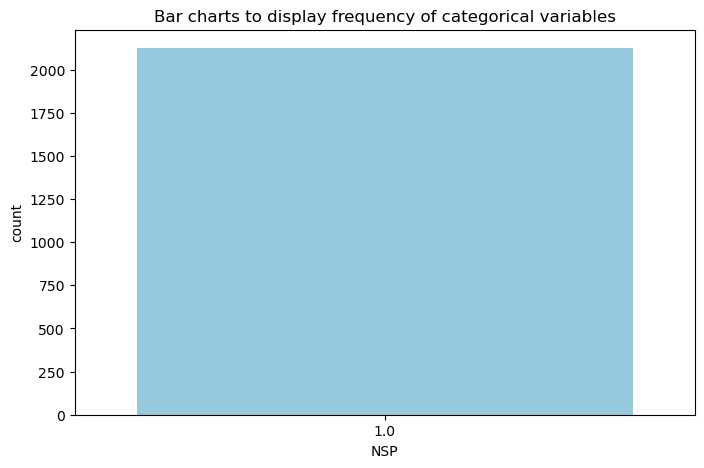

In [83]:
#Bar chart
plt.figure(figsize=(8,5))
sns.countplot(x='NSP',data=df,color='skyblue')
plt.title("Bar charts to display frequency of categorical variables")
plt.show()

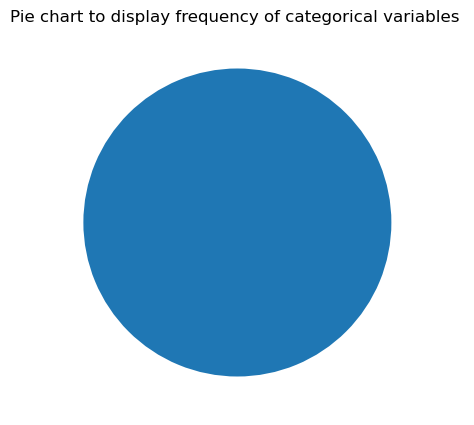

In [85]:
#Pie chart
plt.figure(figsize=(8,5))
plt.pie(df['NSP'].value_counts(),startangle=90)
plt.title("Pie chart to display frequency of categorical variables ")
plt.show()
#Only one categorical column so pie chart is full circle

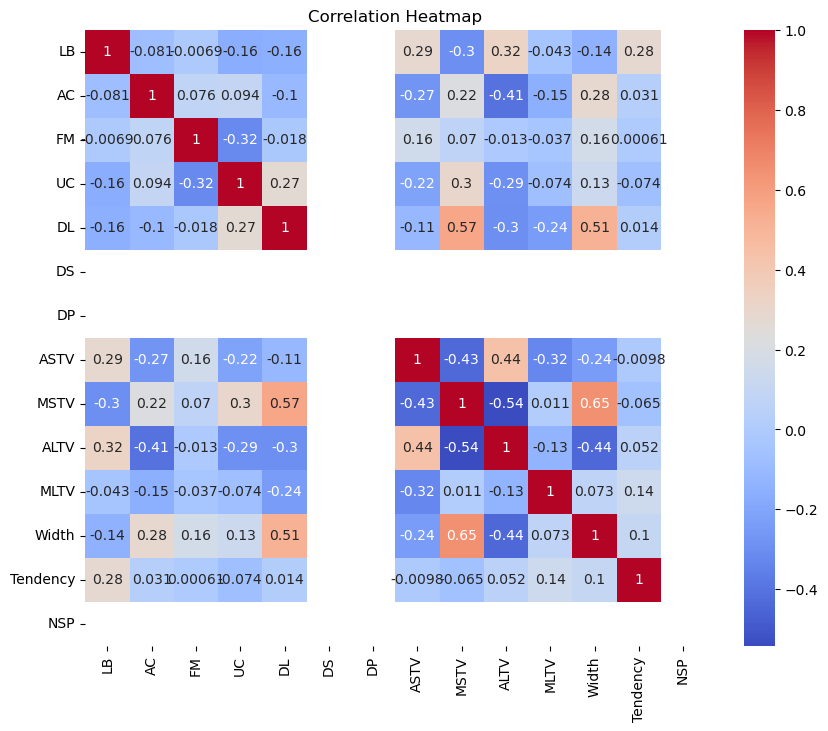

In [87]:
#Correlation map
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


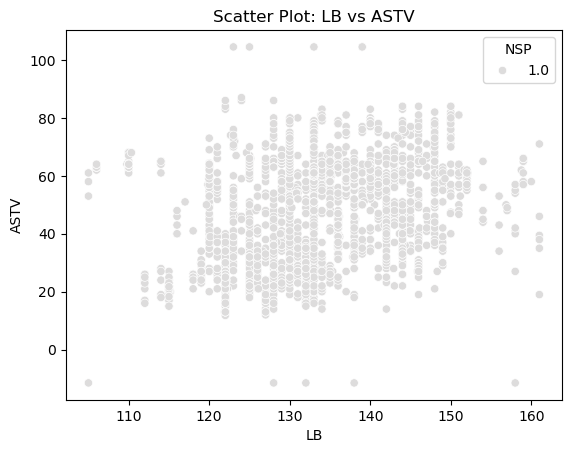

In [93]:
#Scatter plot
sns.scatterplot(x='LB', y='ASTV', data=df, hue='NSP', palette='coolwarm')
plt.title("Scatter Plot: LB vs ASTV")
plt.show()


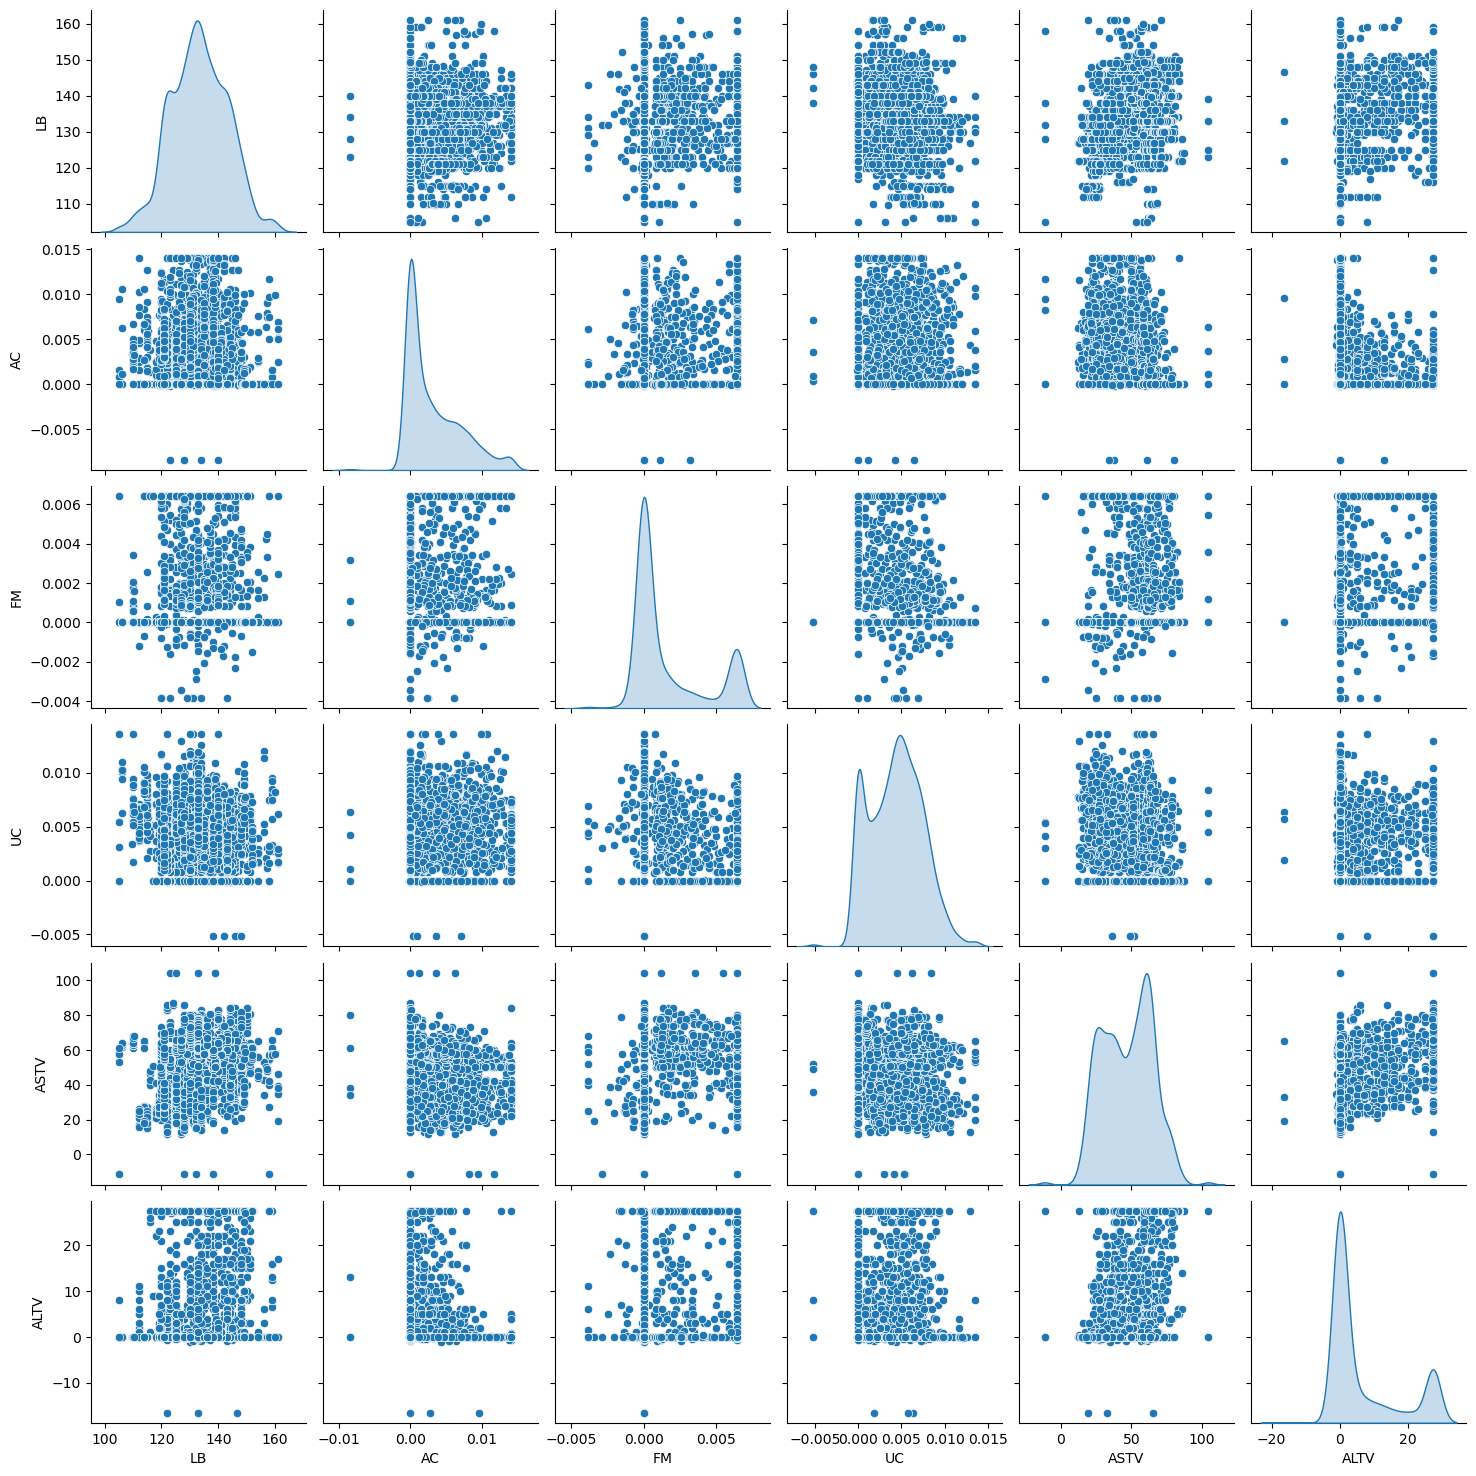

In [95]:
#pair plot
sns.pairplot(df[['LB','AC','FM','UC','ASTV','ALTV']], diag_kind='kde')
plt.show()


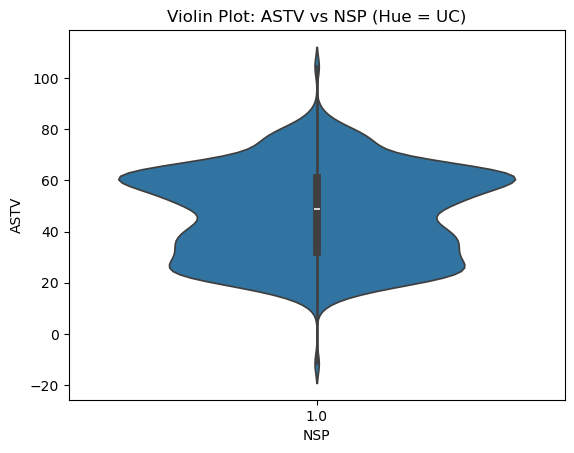

In [109]:
#violin plot
sns.violinplot(x='NSP', y='ASTV', data=df)
plt.title("Violin Plot: ASTV vs NSP (Hue = UC)")
plt.show()


## Visualization Insights

**Histogram :** shows data spread

**Boxplot:** shows outliers

**Bar/Pie chart:** shows category frequencies

**Scatter plot:** shows relationship between two features

**Heatmap:** shows correlation between all numeric columns

**Pair plot:** shows all pairwise relations

**Violin plot:** shows distribution shape for each category

## Patterns Recognition and Insights

**Correlations:**
- Fetal heart rate variability metrics (MSTV, ASTV, ALTV, Width) move together , consistent with physiological variability.
- NSP shows relationships with ASTV and ALTV, hinting they are good classification features.

**Trends:**
- No explicit time variable, so no temporal trend analysis.
- But features like MSTV vs. ASTV show clusters that may align with fetal state categories.

## Conclusion

**Key Insights**

- The dataset is clean, numeric, and model-ready after simple imputation.
- ASTV, ALTV, MSTV, and Width are most informative for predicting fetal states (NSP).
- Some features (like DL, DS, DP) have extreme outliers and may need transformation.
- Features show moderate redundancy — dimensionality reduction (PCA) may help.

**Impact on Modeling**

- Distance-based models (KNN, SVM) should use scaled data (StandardScaler).
- Strong correlations suggest feature selection can reduce overfitting.
- NSP being numeric implies it encodes classes (likely 1–3 for normal/suspect/pathologic).

## Recommendations for Next Steps

- Preprocessing
- Handle missing values with median imputation.
- Apply StandardScaler for model input.
- Modeling
- Use NSP as the target variable.
- Try classification models: KNN, Random Forest, or Logistic Regression.

